# CAFNet Cross-Dataset Zero-Shot Eval: Half-Truth + PartialSpoof

In [1]:
# ==============================================================================
# CELL 1: IMPORTS, CONFIG, PATHS
# ==============================================================================
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import random

from pathlib import Path
from tqdm.auto import tqdm
from scipy.fftpack import dct
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve)

# ── Paths ─────────────────────────────
HALFTRUTH_BASE   = Path("/kaggle/input/datasets/piwoobeep/had-eval")
PARTIALSPOOF_BASE = Path("/kaggle/input/datasets/piwoobeep/partialspoof/PartialSpoof")
CAFNET_CKPT      = Path("/kaggle/input/models/piwoobeep/cafnet/pytorch/default/1/cafnet_no_aux_head_seed42.pth")

WORK_DIR = Path("/kaggle/working")
RESULTS  = WORK_DIR / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

# ── Feature config ─────────────
SR         = 16000
DURATION   = 4.0
HOP        = 256
N_FFT      = 512
N_MFCC     = 40
N_LFCC     = 40
N_CHROMA   = 12
N_FRAMES   = int(SR * DURATION / HOP) + 1   # 251
WIN_DURATION = 4.0

CAF_CLASSES     = 3
CLASS_NAMES_CAF = ["real", "fake", "half-truth"]
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED            = 42

def set_seed(s=42):
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f"Device : {DEVICE}")

Device : cpu


In [8]:
# ==============================================================================
# CELL 2: CAFNET ARCHITECTURE — verbatim from cafnet-test.ipynb / add-finetune.ipynb
# Must match exactly what cafnet_unified.pth was trained with.
# ==============================================================================

class DSConv1d(nn.Module):
    def __init__(self, ic, oc, k, p):
        super().__init__()
        self.dw = nn.Conv1d(ic, ic, k, padding=p, groups=ic)
        self.pw = nn.Conv1d(ic, oc, 1)
    def forward(self, x): return self.pw(self.dw(x))


class SelfAttn1d(nn.Module):
    def __init__(self, ch):
        super().__init__()
        hid = max(ch // 8, 1)
        self.q = nn.Conv1d(ch, hid, 1)
        self.k = nn.Conv1d(ch, hid, 1)
        self.v = nn.Conv1d(ch, ch,  1)
        self.g = nn.Parameter(torch.zeros(1))
    def forward(self, x):
        q = self.q(x).permute(0,2,1)
        a = F.softmax(torch.bmm(q, self.k(x)), dim=-1)
        return self.g * torch.bmm(self.v(x), a.permute(0,2,1)) + x


class EnhancedPath(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.net = nn.Sequential(
            DSConv1d(in_ch, 64, 3, 1), nn.BatchNorm1d(64),
            nn.ReLU(), nn.Dropout(0.3),
            DSConv1d(64, 128, 3, 1),   nn.BatchNorm1d(128),
            nn.ReLU(), nn.Dropout(0.3),
        )
        self.attn = SelfAttn1d(128)
        self.pool = nn.MaxPool1d(2)
    def forward(self, x):
        return self.pool(self.attn(self.net(x.squeeze(1))))


class CrossAttnFusion(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.ca   = nn.MultiheadAttention(dim, num_heads=8, batch_first=True)
        self.gate = nn.Linear(dim*3, 3)
        self.proj = nn.Linear(dim, dim)
    def forward(self, m, l, c):
        ms = m.permute(0,2,1); ls = l.permute(0,2,1); cs = c.permute(0,2,1)
        kv = torch.cat([ls, cs], dim=1)
        attn_out, _ = self.ca(ms, kv, kv)
        mp = ms.mean(1); lp = ls.mean(1); cp = cs.mean(1)
        gates = F.softmax(self.gate(torch.cat([mp,lp,cp], dim=1)), dim=1)
        fused = gates[:,0:1]*mp + gates[:,1:2]*lp + gates[:,2:3]*cp
        return self.proj(fused)   # (B, 128)


class TemporalHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(384, 64, num_layers=2, bidirectional=True,
                            batch_first=True, dropout=0.3)
        self.fc   = nn.Linear(128, 2)
    def forward(self, x):
        out, _ = self.lstm(x.permute(0,2,1))
        return torch.sigmoid(self.fc(out[:,-1,:]))


class CAFNet(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.mfcc_p   = EnhancedPath(N_MFCC)
        self.lfcc_p   = EnhancedPath(N_LFCC)
        self.chroma_p = EnhancedPath(N_CHROMA)
        self.fusion   = CrossAttnFusion(128)
        self.head = nn.Sequential(
            nn.Linear(128,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, n_classes))
        # self.aux REMOVED
        self.temporal = TemporalHead()
    def forward(self, mfcc, lfcc, chroma):
        mf, lf, cf = self.mfcc_p(mfcc), self.lfcc_p(lfcc), self.chroma_p(chroma)
        pre_pool = torch.cat([mf, lf, cf], dim=1)
        fused = self.fusion(mf, lf, cf)
        cls_main = self.head(fused)
        temporal = self.temporal(pre_pool)
        return cls_main, None, temporal 


# ── Load checkpoint ────────────────────────────────────────────────────────
cafnet = CAFNet(n_classes=CAF_CLASSES).to(DEVICE)
cafnet.load_state_dict(torch.load(CAFNET_CKPT, map_location=DEVICE))
cafnet.eval()
n_params = sum(p.numel() for p in cafnet.parameters())
print(f"CAFNet loaded. Params: {n_params:,}")

CAFNet loaded. Params: 576,027


In [2]:
# ==============================================================================
# CELL 3: FEATURE HELPERS — verbatim from cafnet-test.ipynb
# ==============================================================================

def _compute_lfcc(y, sr=SR, n_lfcc=N_LFCC, n_fft=N_FFT, hop=HOP, n_filters=128):
    S     = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop)) ** 2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    centers = np.linspace(0, freqs[-1], n_filters + 2)
    fb = np.zeros((n_filters, len(freqs)), dtype=np.float32)
    for i in range(n_filters):
        fl, fc, fr = centers[i], centers[i+1], centers[i+2]
        for j, f in enumerate(freqs):
            if fl <= f <= fc:
                fb[i, j] = (f - fl) / (fc - fl + 1e-10)
            elif fc < f <= fr:
                fb[i, j] = (fr - f) / (fr - fc + 1e-10)
    log_e = np.log(np.dot(fb, S) + 1e-10)
    return dct(log_e, type=2, axis=0, norm="ortho")[:n_lfcc]


def extract_window_features(y_segment: np.ndarray, n_frames: int = N_FRAMES) -> tuple:
    """
    Given a raw waveform segment of exactly SR*WIN_DURATION samples,
    return (mfcc, lfcc, chroma) each shaped (n_coeff, N_FRAMES).
    Segments shorter than 4s are zero-padded; longer are truncated —
    for Half-Truth/PartialSpoof this needs a windowing strategy decision
    (see Cell 4 TODO) since source clips won't all be exactly 4s like MLADDC T3.
    """
    target = int(SR * WIN_DURATION)
    if len(y_segment) < target:
        y_segment = np.pad(y_segment, (0, target - len(y_segment)))
    else:
        y_segment = y_segment[:target]

    def _fix(arr):
        if arr.shape[1] < n_frames:
            arr = np.pad(arr, ((0, 0), (0, n_frames - arr.shape[1])))
        return arr[:, :n_frames].astype(np.float32)

    mfcc   = _fix(librosa.feature.mfcc(y=y_segment, sr=SR, n_mfcc=N_MFCC,
                                        n_fft=N_FFT, hop_length=HOP))
    lfcc   = _fix(_compute_lfcc(y_segment))
    chroma = _fix(librosa.feature.chroma_stft(y=y_segment, sr=SR,
                                               n_fft=N_FFT, hop_length=HOP))
    return mfcc, lfcc, chroma


def features_to_tensors(mfcc, lfcc, chroma):
    to_t = lambda a: torch.from_numpy(a).unsqueeze(0).unsqueeze(0).to(DEVICE)
    return to_t(mfcc), to_t(lfcc), to_t(chroma)


print("Feature helpers defined.")

Feature helpers defined.


In [3]:
# ==============================================================================
# CELL 4a: HAD (Half-truth Audio Detection) loader
# Label format per line: '<uttid> <seg1>/<seg2>/... <overall>'
#   each seg = 'start-end-T' or 'start-end-F' (T=original, F=replaced)
#   overall  = 1 -> fully unaltered (real), 0 -> contains a replacement
# We further split overall==0 into 'fake' (all segments F, no real audio
# left) vs 'halftruth' (mixed T/F) so CAFNet's 3-class framing is respected
# even though HAD itself is only labeled real/not-real.
# ==============================================================================

HAD_TEST_WAV_DIR   = Path("/kaggle/input/datasets/piwoobeep/had-eval/test/test")
HAD_TEST_LABEL_TXT = Path("/kaggle/input/datasets/piwoobeep/had-eval/HAD_test_label.txt")


def parse_had_labels(label_path):
    """
    Returns dict: uttid -> {
        'overall': int (0/1),
        'segments': [(start_s, end_s, 'T'/'F'), ...],
        'class': 'real' | 'fake' | 'halftruth',
        'splice_start': float or None,   # only set for 'halftruth'
        'splice_end': float or None,
    }
    """
    entries = {}
    with open(label_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            uttid   = parts[0]
            seg_str = parts[1]
            overall = int(parts[2])

            segs = []
            for seg in seg_str.split('/'):
                start_s, end_s, lab = seg.rsplit('-', 2)[0], seg.rsplit('-', 2)[1], seg.rsplit('-', 2)[2]
                segs.append((float(start_s), float(end_s), lab))

            labels_present = set(s[2] for s in segs)
            if overall == 1:
                cls = 'real'
            elif labels_present == {'F'}:
                cls = 'fake'
            else:
                cls = 'halftruth'

            splice_start = splice_end = None
            if cls == 'halftruth':
                f_segs = [s for s in segs if s[2] == 'F']
                # HAD allows multiple replaced regions per clip; take the outer
                # envelope (first F start -> last F end) since CAFNet predicts
                # a single [start,end] span. Flag multi-region clips separately
                # so they can be excluded from a strict single-splice eval if desired.
                splice_start = min(s[0] for s in f_segs)
                splice_end   = max(s[1] for s in f_segs)

            entries[uttid] = {
                'overall': overall,
                'segments': segs,
                'class': cls,
                'splice_start': splice_start,
                'splice_end': splice_end,
                'n_f_regions': sum(1 for s in segs if s[2] == 'F'),
            }
    return entries


had_entries = parse_had_labels(HAD_TEST_LABEL_TXT)
print(f"HAD test entries: {len(had_entries)}")
from collections import Counter
print(Counter(v['class'] for v in had_entries.values()))

# (wav_path, binary_label) list for the collapsed real-vs-not-real eval,
# consistent with the convention already used in the paper's cross-dataset table.
had_binary_examples = [
    (HAD_TEST_WAV_DIR / f"{uttid}.wav", 0 if e['class'] == 'real' else 1)
    for uttid, e in had_entries.items()
]
print(f"HAD binary eval examples: {len(had_binary_examples)}")

# Halftruth-only subset with single-region splices, for a localization check
# (mirrors Table 'Temporal boundary localisation on MLADDC T3' in the paper).
had_halftruth_single = {
    uttid: e for uttid, e in had_entries.items()
    if e['class'] == 'halftruth' and e['n_f_regions'] == 1
}
print(f"HAD single-splice half-truth clips: {len(had_halftruth_single)} "
      f"(of {sum(1 for e in had_entries.values() if e['class']=='halftruth')} total half-truth)")

HAD test entries: 9072
Counter({'halftruth': 8838, 'fake': 234})
HAD binary eval examples: 9072
HAD single-splice half-truth clips: 8838 (of 8838 total half-truth)


In [5]:
# ==============================================================================
# CELL 4b: PartialSpoof loader
# Overall bonafide/spoof label comes from the CM protocol file (same format
# as ASVspoof2019: SPEAKER_ID AUDIO_FILE_NAME - SYSTEM_ID KEY).
# We restrict to CON_* files for the half-truth-style comparison — those are
# the partially-spoofed clips; LA_* files are the original ASVspoof2019
# fully-real/fully-fake audio and are NOT the target task here (that's what
# the existing FoR/WaveFake/ASVspoof cross-dataset table already covers).
# Splice boundaries come from the .vad files: label 0=spoof, 1=bonafide,
# 2=non-speech. We merge contiguous spoof(0) intervals to get the splice span,
# same single-vs-multi-region caveat as HAD above.
# ==============================================================================

PS_EVAL_WAV_DIR   = Path("/kaggle/input/datasets/piwoobeep/partialspoof/PartialSpoof/con_wav")
PS_EVAL_PROTOCOL  = Path("/kaggle/input/datasets/piwoobeep/partialspoof/PartialSpoof/protocols/PartialSpoof_LA_cm_protocols/PartialSpoof.LA.cm.eval.trl.txt")
PS_EVAL_VAD_DIR   = Path("/kaggle/input/datasets/piwoobeep/partialspoof/PartialSpoof/eval")


def parse_partialspoof_protocol(protocol_path):
    """fname -> {'system': sysid, 'key': 'bonafide'/'spoof'}"""
    entries = {}
    with open(protocol_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            spk, fname, dash, sysid, key = parts[:5]
            entries[fname] = {'system': sysid, 'key': key}
    return entries


def parse_vad_file(vad_path):
    """Returns list of (start, end, label) with label in {0,1,2}."""
    intervals = []
    with open(vad_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 3:
                continue
            st, et, lab = float(parts[0]), float(parts[1]), int(parts[2])
            intervals.append((st, et, lab))
    return intervals


def merge_spoof_span(vad_intervals):
    """Collapse label==0 (spoof) intervals to an outer [start, end] envelope.
    Returns (start, end, n_regions) or (None, None, 0) if no spoof intervals.
    """
    spoof = [(s, e) for s, e, lab in vad_intervals if lab == 0]
    if not spoof:
        return None, None, 0
    return min(s for s, e in spoof), max(e for s, e in spoof), len(spoof)


ps_protocol = parse_partialspoof_protocol(PS_EVAL_PROTOCOL)
ps_con_entries = {f: v for f, v in ps_protocol.items() if f.startswith('CON_')}
print(f"PartialSpoof eval protocol entries: {len(ps_protocol)}, CON_* subset: {len(ps_con_entries)}")
print(Counter(v['key'] for v in ps_con_entries.values()))

# (wav_path, binary_label) — 0 real(bonafide) / 1 not-real(spoof), CON_* only
partialspoof_binary_examples = [
    (PS_EVAL_WAV_DIR / f"{fname}.wav", 0 if v['key'] == 'bonafide' else 1)
    for fname, v in ps_con_entries.items()
]
print(f"PartialSpoof CON_* binary eval examples: {len(partialspoof_binary_examples)}")

# Splice-span lookup for CON_* spoof clips (single-region subset, for localization)
ps_splice_single = {}
for fname, v in ps_con_entries.items():
    if v['key'] != 'spoof':
        continue
    vad_path = PS_EVAL_VAD_DIR / f"{fname}.vad"
    if not vad_path.exists():
        continue
    start, end, n_regions = merge_spoof_span(parse_vad_file(vad_path))
    if start is not None and n_regions == 1:
        ps_splice_single[fname] = {'splice_start': start, 'splice_end': end}
print(f"PartialSpoof single-region spoof spans resolved: {len(ps_splice_single)}")

# ── FIX: CON_* alone has no bonafide class (by construction every CON_*
# entry contains a spliced spoof segment, so protocol key is always 'spoof').
# Pull LA_* bonafide entries from the same protocol as the 'real' class —
# these are the original, unmodified ASVspoof2019 bonafide utterances from
# the same speaker pool, so it's a fair like-for-like pairing.
# ==============================================================================

PS_EVAL_LA_WAV_DIR = PARTIALSPOOF_BASE / "con_wav"   # LA_* originals ship in the same con_wav dir

ps_la_bonafide = {f: v for f, v in ps_protocol.items()
                   if f.startswith('LA_') and v['key'] == 'bonafide'}
print(f"PartialSpoof LA_* bonafide entries: {len(ps_la_bonafide)}")

# Combined binary eval set: LA_* bonafide (real=0) + CON_* spoof (not-real=1).
# Subsampled with the fixed SEED to keep eval runtime sane — full CON_* alone
# is 63,882 clips; bump N_PER_CLASS up if you have the compute budget.
N_PER_CLASS = 7000
rng = random.Random(SEED)

la_sample  = rng.sample(list(ps_la_bonafide.keys()), min(N_PER_CLASS, len(ps_la_bonafide)))
con_sample = rng.sample(list(ps_con_entries.keys()), min(N_PER_CLASS, len(ps_con_entries)))

partialspoof_binary_examples = (
    [(PS_EVAL_LA_WAV_DIR / f"{f}.wav", 0) for f in la_sample] +
    [(PS_EVAL_WAV_DIR    / f"{f}.wav", 1) for f in con_sample]
)
print(f"PartialSpoof combined binary eval set: {len(partialspoof_binary_examples)} "
      f"({len(la_sample)} real / {len(con_sample)} not-real)")


PartialSpoof eval protocol entries: 71237, CON_* subset: 63882
Counter({'spoof': 63882})
PartialSpoof CON_* binary eval examples: 63882
PartialSpoof single-region spoof spans resolved: 0
PartialSpoof LA_* bonafide entries: 7355
PartialSpoof combined binary eval set: 14000 (7000 real / 7000 not-real)


In [6]:
# ==============================================================================
# CELL 5: EVAL FUNCTIONS
# eval_zero_shot_binary: for sets with both classes present (PartialSpoof).
# eval_detection_rate:   for single-class sets (HAD) — no negative class
# exists in this file, so AUC/EER are undefined; report recall instead,
# broken down by source class (fake vs halftruth) so you can see whether
# CAFNet's known real-class-imbalance behavior generalizes zero-shot.
# ==============================================================================

def compute_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return brentq(lambda x: 1 - x - interp1d(fpr, tpr)(x), 0, 1)


def _predict_not_real_score(model, wav_path):
    y, _ = librosa.load(str(wav_path), sr=SR, mono=True)
    mfcc, lfcc, chroma = extract_window_features(y)
    m, l, c = features_to_tensors(mfcc, lfcc, chroma)
    with torch.no_grad():
        logits, _, _ = model(m, l, c)
    probs = F.softmax(logits, dim=1).cpu().numpy()[0]
    return probs[1] + probs[2]   # P(fake) + P(half-truth)


def eval_zero_shot_binary(model, examples, device):
    """examples: list of (wav_path, label) with label=0 real, 1 not-real.
    Requires BOTH classes present or AUC/EER are undefined."""
    model.eval()
    scores, labels = [], []
    for wav_path, label in tqdm(examples, desc="binary eval"):
        scores.append(_predict_not_real_score(model, wav_path))
        labels.append(label)
    scores, labels = np.array(scores), np.array(labels)
    if len(set(labels)) < 2:
        raise ValueError("Only one class present — use eval_detection_rate instead.")
    auc = roc_auc_score(labels, scores)
    eer = compute_eer(labels, scores)
    best_acc = max(accuracy_score(labels, (scores >= t).astype(int))
                   for t in np.linspace(0.01, 0.99, 99))
    return {"auc": auc, "eer": eer, "acc": best_acc, "n": len(examples)}


def eval_detection_rate(model, entries_dict, wav_dir, device, threshold=0.5):
    """entries_dict: uttid -> {'class': 'fake'/'halftruth', ...} (all positives,
    i.e. all 'not-real' — there's no bonafide class in this file). Reports
    recall overall and split by source class.
    """
    model.eval()
    hits = {'fake': [], 'halftruth': []}
    for uttid, e in tqdm(entries_dict.items(), desc="detection rate"):
        wav_path = wav_dir / f"{uttid}.wav"
        score = _predict_not_real_score(model, wav_path)
        hits[e['class']].append(int(score >= threshold))
    out = {}
    for cls, vals in hits.items():
        if vals:
            out[cls] = {"recall": float(np.mean(vals)), "n": len(vals)}
    all_vals = [v for vs in hits.values() for v in vs]
    out['overall'] = {"recall": float(np.mean(all_vals)) if all_vals else float('nan'),
                       "n": len(all_vals)}
    return out


print("Eval functions defined: eval_zero_shot_binary (needs 2 classes), "
      "eval_detection_rate (single-class, e.g. HAD).")

def eval_paired_rate(model, examples, device):
    """examples: list of (wav_path, label), label=0 real / 1 not-real.
    Reports TPR (recall on not-real, i.e. detection rate) and FPR (rate at
    which genuine real audio is wrongly flagged as not-real) separately,
    instead of collapsing into AUC/EER which hides the asymmetry."""
    model.eval()
    real_scores, notreal_scores = [], []
    for wav_path, label in tqdm(examples, desc="paired rate eval"):
        score = _predict_not_real_score(model, wav_path)
        (real_scores if label == 0 else notreal_scores).append(score)
    real_scores    = np.array(real_scores)
    notreal_scores = np.array(notreal_scores)
    tpr = float(np.mean(notreal_scores >= 0.5))   # correctly flags not-real
    fpr = float(np.mean(real_scores    >= 0.5))   # wrongly flags real as not-real
    return {
        "tpr_detection_rate": tpr, "n_notreal": len(notreal_scores),
        "fpr_false_alarm_rate": fpr, "n_real": len(real_scores),
    }

Eval functions defined: eval_zero_shot_binary (needs 2 classes), eval_detection_rate (single-class, e.g. HAD).


In [7]:
# ==============================================================================
# CELL 6 
# ==============================================================================

print("=" * 70)
print("HAD — detection rate (no bonafide class in this file, see note above)")
print("=" * 70)
had_results = eval_detection_rate(cafnet, had_entries, HAD_TEST_WAV_DIR, DEVICE)
for k, v in had_results.items():
    print(f"  {k:12s} recall={v['recall']:.4f}  (n={v['n']})")

print()
print("=" * 70)
print("PartialSpoof — zero-shot binary AUC/EER (LA_* bonafide vs CON_* spoof)")
print("=" * 70)
ps_results = eval_zero_shot_binary(cafnet, partialspoof_binary_examples, DEVICE)
print(f"  AUC={ps_results['auc']:.4f}  EER={ps_results['eer']:.4f}  "
      f"Acc={ps_results['acc']:.4f}  (n={ps_results['n']})")
print("=" * 70)
print("PartialSpoof — paired TPR/FPR (separates detection from false-alarm rate)")
print("=" * 70)
ps_paired = eval_paired_rate(cafnet, partialspoof_binary_examples, DEVICE)
print(f"  Detection rate (TPR on CON_*):     {ps_paired['tpr_detection_rate']:.4f}  (n={ps_paired['n_notreal']})")
print(f"  False-alarm rate (FPR on LA_* real): {ps_paired['fpr_false_alarm_rate']:.4f}  (n={ps_paired['n_real']})")


HAD — detection rate (no bonafide class in this file, see note above)


detection rate:   0%|          | 0/9072 [00:00<?, ?it/s]

  fake         recall=0.9316  (n=234)
  halftruth    recall=0.8469  (n=8838)
  overall      recall=0.8491  (n=9072)

PartialSpoof — zero-shot binary AUC/EER (LA_* bonafide vs CON_* spoof)


binary eval:   0%|          | 0/14000 [00:00<?, ?it/s]

  AUC=0.5544  EER=0.4524  Acc=0.5501  (n=14000)
PartialSpoof — paired TPR/FPR (separates detection from false-alarm rate)


paired rate eval:   0%|          | 0/14000 [00:00<?, ?it/s]

  Detection rate (TPR on CON_*):     0.8989  (n=7000)
  False-alarm rate (FPR on LA_* real): 0.9231  (n=7000)


In [8]:
# ==============================================================================
# CELL 7: Manual sanity check — raw softmax on a handful of PartialSpoof
# examples from each class, to rule out a labeling-direction bug before the
# near-chance AUC goes into the paper.
# ==============================================================================

def inspect_examples(model, examples, n=8, label_names=("real", "not-real")):
    model.eval()
    reals   = [e for e in examples if e[1] == 0][:n]
    notreal = [e for e in examples if e[1] == 1][:n]
    print(f"{'file':40s} {'true':10s} {'P(real)':>9s} {'P(fake)':>9s} {'P(half-truth)':>14s} {'pred':>10s}")
    print("-" * 95)
    for wav_path, label in reals + notreal:
        y, _ = librosa.load(str(wav_path), sr=SR, mono=True)
        mfcc, lfcc, chroma = extract_window_features(y)
        m, l, c = features_to_tensors(mfcc, lfcc, chroma)
        with torch.no_grad():
            logits, _, _ = model(m, l, c)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred = CLASS_NAMES_CAF[probs.argmax()]
        print(f"{wav_path.name:40s} {label_names[label]:10s} "
              f"{probs[0]:9.4f} {probs[1]:9.4f} {probs[2]:14.4f} {pred:>10s}")

inspect_examples(cafnet, partialspoof_binary_examples, n=8)

file                                     true         P(real)   P(fake)  P(half-truth)       pred
-----------------------------------------------------------------------------------------------
LA_E_5996278.wav                         real          0.2840    0.4097         0.3063       fake
LA_E_9305857.wav                         real          0.0704    0.5345         0.3951       fake
LA_E_1137766.wav                         real          0.0923    0.6783         0.2294       fake
LA_E_7484573.wav                         real          0.0005    0.9955         0.0039       fake
LA_E_5504758.wav                         real          0.0374    0.8821         0.0805       fake
LA_E_5493892.wav                         real          0.0016    0.9966         0.0018       fake
LA_E_7975182.wav                         real          0.0159    0.0728         0.9113 half-truth
LA_E_1350734.wav                         real          0.0805    0.0754         0.8441 half-truth
CON_E_0042724.wav     

In [9]:
# ==============================================================================
# CELL 8.2: HAD sanity check — validates both the label parsing itself and
# the model's predictions on a handful of examples from each class.
# ==============================================================================

import random as _r
_rng = _r.Random(SEED)

# --- Part 1: parsing sanity — confirm segment boundaries and class assignment
# look right against the raw label line, independent of the model entirely.
print("Parsing sanity — raw line vs parsed entry")
print("-" * 95)
sample_uttids = _rng.sample(list(had_entries.keys()), 5)
with open(HAD_TEST_LABEL_TXT) as f:
    raw_lines = {line.split()[0]: line.strip() for line in f}

for uttid in sample_uttids:
    e = had_entries[uttid]
    print(f"raw:    {raw_lines[uttid]}")
    print(f"parsed: class={e['class']:10s} overall={e['overall']} "
          f"n_segments={len(e['segments'])} n_f_regions={e['n_f_regions']} "
          f"splice=({e['splice_start']}, {e['splice_end']})")
    print()

# --- Part 2: model predictions — same table format as the PartialSpoof check,
# sampled across both HAD classes (no 'real' class exists in this file).
print("=" * 95)
print("Model predictions on sampled HAD examples")
print("=" * 95)

def inspect_had_examples(model, entries_dict, wav_dir, n=8):
    model.eval()
    fake_ids      = [u for u, e in entries_dict.items() if e['class'] == 'fake']
    halftruth_ids = [u for u, e in entries_dict.items() if e['class'] == 'halftruth']
    sample_ids = _rng.sample(fake_ids, min(n, len(fake_ids))) + \
                 _rng.sample(halftruth_ids, min(n, len(halftruth_ids)))

    print(f"{'file':22s} {'true class':10s} {'P(real)':>9s} {'P(fake)':>9s} "
          f"{'P(half-truth)':>14s} {'pred':>10s}")
    print("-" * 80)
    for uttid in sample_ids:
        wav_path = wav_dir / f"{uttid}.wav"
        y, _ = librosa.load(str(wav_path), sr=SR, mono=True)
        mfcc, lfcc, chroma = extract_window_features(y)
        m, l, c = features_to_tensors(mfcc, lfcc, chroma)
        with torch.no_grad():
            logits, _, _ = model(m, l, c)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred = CLASS_NAMES_CAF[probs.argmax()]
        true_cls = entries_dict[uttid]['class']
        print(f"{uttid:22s} {true_cls:10s} {probs[0]:9.4f} {probs[1]:9.4f} "
              f"{probs[2]:14.4f} {pred:>10s}")

inspect_had_examples(cafnet, had_entries, HAD_TEST_WAV_DIR, n=8)

Parsing sanity — raw line vs parsed entry
-----------------------------------------------------------------------------------------------
raw:    HAD_test_00001825 0.00-0.46-F/0.46-2.98-T 0
parsed: class=halftruth  overall=0 n_segments=2 n_f_regions=1 splice=(0.0, 0.46)

raw:    HAD_test_00000410 0.00-1.34-T/1.34-2.10-F/2.10-3.42-T 0
parsed: class=halftruth  overall=0 n_segments=3 n_f_regions=1 splice=(1.34, 2.1)

raw:    HAD_test_00004507 0.00-1.24-T/1.24-1.72-F/1.72-3.70-T 0
parsed: class=halftruth  overall=0 n_segments=3 n_f_regions=1 splice=(1.24, 1.72)

raw:    HAD_test_00004013 0.00-0.33-T/0.33-1.23-F/1.23-3.20-T 0
parsed: class=halftruth  overall=0 n_segments=3 n_f_regions=1 splice=(0.33, 1.23)

raw:    HAD_test_00003658 0.00-0.61-T/0.61-1.23-F/1.23-6.92-T 0
parsed: class=halftruth  overall=0 n_segments=3 n_f_regions=1 splice=(0.61, 1.23)

Model predictions on sampled HAD examples
file                   true class   P(real)   P(fake)  P(half-truth)       pred
-------------------

In [10]:
# ==============================================================================
# CELL 8.3: Does CAFNet ever predict 'half-truth' on HAD at all?
# ==============================================================================

from collections import Counter as _Counter

def full_prediction_distribution(model, entries_dict, wav_dir):
    model.eval()
    pred_by_true_class = {'fake': [], 'halftruth': []}
    for uttid, e in tqdm(entries_dict.items(), desc="full prediction pass"):
        wav_path = wav_dir / f"{uttid}.wav"
        y, _ = librosa.load(str(wav_path), sr=SR, mono=True)
        mfcc, lfcc, chroma = extract_window_features(y)
        m, l, c = features_to_tensors(mfcc, lfcc, chroma)
        with torch.no_grad():
            logits, _, _ = model(m, l, c)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred = CLASS_NAMES_CAF[probs.argmax()]
        pred_by_true_class[e['class']].append(pred)
    for cls, preds in pred_by_true_class.items():
        print(f"true={cls:10s}  pred distribution: {dict(_Counter(preds))}")

full_prediction_distribution(cafnet, had_entries, HAD_TEST_WAV_DIR)

full prediction pass:   0%|          | 0/9072 [00:00<?, ?it/s]

true=fake        pred distribution: {'fake': 216, 'half-truth': 2, 'real': 16}
true=halftruth   pred distribution: {'real': 1499, 'fake': 2881, 'half-truth': 4458}


In [11]:
# ==============================================================================
# CELL 8.4 (REVISED): Temporal localization on HAD — random-offset oracle
# window. Still guarantees the splice fully falls inside the 4s window
# (that part of the oracle is unavoidable — the model needs the splice
# present at all), but the window's start position is now drawn uniformly
# at random from every valid offset, instead of always centering the
# splice. This matches MLADDC's training distribution, where the splice
# lands at a random position within the 4s clip, not a fixed one.
# ==============================================================================

_offset_rng = random.Random(SEED)

def random_offset_crop_and_predict(model, y, splice_start, splice_end, sr=SR, win_dur=WIN_DURATION):
    duration = len(y) / sr
    splice_dur = splice_end - splice_start

    if duration <= win_dur:
        # clip shorter than the window — no choice of offset, use the whole clip
        win_start, win_end = 0.0, duration
    else:
        # valid win_start range: window must start at or before splice_start,
        # and end at or after splice_end
        lower = max(0.0, splice_end - win_dur)
        upper = min(splice_start, duration - win_dur)
        if upper < lower:
            # shouldn't happen given splice_dur <= win_dur and duration >= win_dur,
            # but fall back to centering if it ever does
            center = (splice_start + splice_end) / 2.0
            win_start = max(0.0, min(center - win_dur / 2.0, duration - win_dur))
        else:
            win_start = _offset_rng.uniform(lower, upper)
        win_end = win_start + win_dur

    y_seg = y[int(win_start * sr): int(win_end * sr)]
    mfcc, lfcc, chroma = extract_window_features(y_seg)
    m, l, c = features_to_tensors(mfcc, lfcc, chroma)
    with torch.no_grad():
        _, _, temp = model(m, l, c)
    pred_start_s = temp[0, 0].item() * win_dur
    pred_end_s   = temp[0, 1].item() * win_dur

    true_start_rel = max(0.0, splice_start - win_start)
    true_end_rel   = min(win_dur, splice_end - win_start)
    return pred_start_s, pred_end_s, true_start_rel, true_end_rel


start_errs, end_errs = [], []
skipped_too_long = 0

for uttid, e in tqdm(had_halftruth_single.items(), desc="HAD localization (random-offset)"):
    splice_dur = e['splice_end'] - e['splice_start']
    if splice_dur > WIN_DURATION:
        skipped_too_long += 1
        continue
    wav_path = HAD_TEST_WAV_DIR / f"{uttid}.wav"
    y, _ = librosa.load(str(wav_path), sr=SR, mono=True)
    pred_s, pred_e, true_s, true_e = random_offset_crop_and_predict(
        cafnet, y, e['splice_start'], e['splice_end'])
    start_errs.append(abs(pred_s - true_s))
    end_errs.append(abs(pred_e - true_e))

start_errs, end_errs = np.array(start_errs), np.array(end_errs)
overall_errs = np.concatenate([start_errs, end_errs])

print(f"Skipped (splice longer than {WIN_DURATION}s window): {skipped_too_long}")
print(f"Evaluated: {len(start_errs)} clips\n")
for name, arr in [("Start", start_errs), ("End", end_errs), ("Overall", overall_errs)]:
    print(f"  {name:8s}  MAE={arr.mean():.3f}s  Median={np.median(arr):.3f}s  "
          f"p90={np.percentile(arr,90):.3f}s")

HAD localization (random-offset):   0%|          | 0/8838 [00:00<?, ?it/s]

Skipped (splice longer than 4.0s window): 7
Evaluated: 8831 clips

  Start     MAE=0.680s  Median=0.502s  p90=1.589s
  End       MAE=0.841s  Median=0.618s  p90=2.015s
  Overall   MAE=0.761s  Median=0.541s  p90=1.826s


In [12]:
# ==============================================================================
# CELL 8.5: Duration/padding diagnostic — how much of the 4s CAFNet window
# is real audio vs zero-padding for PartialSpoof clips? MLADDC training clips
# are cropped from 10-20s sources, so the model likely never saw padded
# silence at train time — if PartialSpoof clips are mostly 2-3s, a large
# fraction of the input becomes trailing zeros, which is a real domain shift
# on top of (or possibly instead of) genuine acoustic generalization failure.
# ==============================================================================

def duration_stats(examples, label_filter, n_sample=200):
    paths = [p for p, l in examples if l == label_filter]
    sample = _rng.sample(paths, min(n_sample, len(paths)))
    durations = np.array([librosa.get_duration(path=str(p)) for p in sample])
    return durations

real_durs    = duration_stats(partialspoof_binary_examples, 0)
notreal_durs = duration_stats(partialspoof_binary_examples, 1)

for name, durs in [("LA_* real", real_durs), ("CON_* not-real", notreal_durs)]:
    pad_frac = np.clip((WIN_DURATION - durs) / WIN_DURATION, 0, 1)
    print(f"{name}: n={len(durs)}  mean={durs.mean():.2f}s  median={np.median(durs):.2f}s  "
          f"min={durs.min():.2f}s  max={durs.max():.2f}s")
    print(f"  -> mean fraction of the 4s window that is zero-padding: {pad_frac.mean():.1%}")
    print(f"  -> fraction of clips needing padding (dur < 4s): {(durs < WIN_DURATION).mean():.1%}")
    print()

LA_* real: n=200  mean=3.38s  median=3.28s  min=1.58s  max=6.99s
  -> mean fraction of the 4s window that is zero-padding: 20.1%
  -> fraction of clips needing padding (dur < 4s): 74.0%

CON_* not-real: n=200  mean=3.46s  median=2.98s  min=0.76s  max=11.06s
  -> mean fraction of the 4s window that is zero-padding: 26.5%
  -> fraction of clips needing padding (dur < 4s): 69.0%



In [13]:
# ==============================================================================
# CELL 9.1: VAD-trimmed feature extraction — removes VAD-labeled non-speech
# regions (label 2) before the 4s zero-pad/truncate step, instead of feeding
# CAFNet the raw (possibly silence-padded) full-duration clip. Falls back to
# librosa energy-based trimming if a clip has no .vad file (e.g. some LA_*
# entries may not be VAD-annotated) — n_fallback in the result dict tells you
# how often that happened, so the VAD-vs-fallback split stays visible.
# ==============================================================================

def load_vad_speech_span(vad_path):
    """(start, end) merged span of all label != 2 (non-'non-speech')
    intervals in a .vad file. Returns None if missing or empty."""
    if not vad_path.exists():
        return None
    intervals = parse_vad_file(vad_path)          # defined in Cell 4b
    speech = [(s, e) for s, e, lab in intervals if lab != 2]
    if not speech:
        return None
    return min(s for s, e in speech), max(e for s, e in speech)


def energy_trim_span(y, sr=SR, top_db=30):
    """Fallback silence trim when no .vad file exists for a clip."""
    _, index = librosa.effects.trim(y, top_db=top_db)
    return index[0] / sr, index[1] / sr


def extract_vad_trimmed_features(wav_path, vad_dir):
    y, _ = librosa.load(str(wav_path), sr=SR, mono=True)
    vad_path = vad_dir / f"{wav_path.stem}.vad"
    span = load_vad_speech_span(vad_path)
    source = "vad"
    if span is None:
        span = energy_trim_span(y)
        source = "energy_fallback"
    start_s, end_s = span
    start_i, end_i = int(start_s * SR), int(end_s * SR)
    y_trimmed = y[start_i:end_i] if end_i > start_i else y
    mfcc, lfcc, chroma = extract_window_features(y_trimmed)
    return (mfcc, lfcc, chroma), source, (end_s - start_s)


def _predict_not_real_score_vad(model, wav_path, vad_dir):
    (mfcc, lfcc, chroma), source, trimmed_dur = extract_vad_trimmed_features(wav_path, vad_dir)
    m, l, c = features_to_tensors(mfcc, lfcc, chroma)
    with torch.no_grad():
        logits, _, _ = model(m, l, c)
    probs = F.softmax(logits, dim=1).cpu().numpy()[0]
    return probs[1] + probs[2], source, trimmed_dur


print("VAD-trimmed feature extraction defined.")

VAD-trimmed feature extraction defined.


In [14]:
# ==============================================================================
# CELL 9.2: Re-run PartialSpoof zero-shot eval on VAD-trimmed features and
# compare directly against the untrimmed baseline from Cell 8 (ps_results /
# ps_paired). Tests whether the false-alarm bias is attributable to
# zero-padding rather than a genuine acoustic-domain mismatch.
# ==============================================================================

def eval_zero_shot_binary_vad(model, examples, vad_dir):
    model.eval()
    scores, labels, sources, durs = [], [], [], []
    for wav_path, label in tqdm(examples, desc="VAD-trimmed binary eval"):
        score, source, dur = _predict_not_real_score_vad(model, wav_path, vad_dir)
        scores.append(score); labels.append(label)
        sources.append(source); durs.append(dur)
    scores, labels = np.array(scores), np.array(labels)
    auc = roc_auc_score(labels, scores)
    eer = compute_eer(labels, scores)
    best_acc = max(accuracy_score(labels, (scores >= t).astype(int))
                    for t in np.linspace(0.01, 0.99, 99))
    n_fallback = sum(1 for s in sources if s == "energy_fallback")
    return {
        "auc": auc, "eer": eer, "acc": best_acc, "n": len(examples),
        "n_fallback": n_fallback,
        "mean_trimmed_dur": float(np.mean(durs)),
    }


def eval_paired_rate_vad(model, examples, vad_dir):
    model.eval()
    real_scores, notreal_scores = [], []
    for wav_path, label in tqdm(examples, desc="VAD-trimmed paired eval"):
        score, _, _ = _predict_not_real_score_vad(model, wav_path, vad_dir)
        (real_scores if label == 0 else notreal_scores).append(score)
    real_scores, notreal_scores = np.array(real_scores), np.array(notreal_scores)
    tpr = float(np.mean(notreal_scores >= 0.5))
    fpr = float(np.mean(real_scores >= 0.5))
    return {
        "tpr_detection_rate": tpr, "n_notreal": len(notreal_scores),
        "fpr_false_alarm_rate": fpr, "n_real": len(real_scores),
    }


print("=" * 70)
print("PartialSpoof — VAD-trimmed zero-shot binary AUC/EER")
print("=" * 70)
ps_results_vad = eval_zero_shot_binary_vad(cafnet, partialspoof_binary_examples, PS_EVAL_VAD_DIR)
print(f"  AUC={ps_results_vad['auc']:.4f}  EER={ps_results_vad['eer']:.4f}  "
      f"Acc={ps_results_vad['acc']:.4f}  (n={ps_results_vad['n']})")
print(f"  Fell back to energy-trim (no .vad file): {ps_results_vad['n_fallback']} / {ps_results_vad['n']}")
print(f"  Mean trimmed duration: {ps_results_vad['mean_trimmed_dur']:.2f}s "
      f"(vs {WIN_DURATION:.1f}s window)")

print()
print("=" * 70)
print("PartialSpoof — VAD-trimmed paired TPR/FPR")
print("=" * 70)
ps_paired_vad = eval_paired_rate_vad(cafnet, partialspoof_binary_examples, PS_EVAL_VAD_DIR)
print(f"  Detection rate (TPR on CON_*):       {ps_paired_vad['tpr_detection_rate']:.4f}  (n={ps_paired_vad['n_notreal']})")
print(f"  False-alarm rate (FPR on LA_* real):  {ps_paired_vad['fpr_false_alarm_rate']:.4f}  (n={ps_paired_vad['n_real']})")

print()
print("=" * 70)
print("Baseline vs. VAD-trimmed — side by side")
print("=" * 70)
print(f"{'Metric':<28s}{'Baseline':>12s}{'VAD-trimmed':>14s}")
print(f"{'AUC':<28s}{ps_results['auc']:>12.4f}{ps_results_vad['auc']:>14.4f}")
print(f"{'EER':<28s}{ps_results['eer']:>12.4f}{ps_results_vad['eer']:>14.4f}")
print(f"{'Accuracy':<28s}{ps_results['acc']:>12.4f}{ps_results_vad['acc']:>14.4f}")
print(f"{'TPR (CON_* detection)':<28s}{ps_paired['tpr_detection_rate']:>12.4f}{ps_paired_vad['tpr_detection_rate']:>14.4f}")
print(f"{'FPR (LA_* false alarm)':<28s}{ps_paired['fpr_false_alarm_rate']:>12.4f}{ps_paired_vad['fpr_false_alarm_rate']:>14.4f}")

PartialSpoof — VAD-trimmed zero-shot binary AUC/EER


VAD-trimmed binary eval:   0%|          | 0/14000 [00:00<?, ?it/s]

  AUC=0.2925  EER=0.6563  Acc=0.4969  (n=14000)
  Fell back to energy-trim (no .vad file): 0 / 14000
  Mean trimmed duration: 2.41s (vs 4.0s window)

PartialSpoof — VAD-trimmed paired TPR/FPR


VAD-trimmed paired eval:   0%|          | 0/14000 [00:00<?, ?it/s]

  Detection rate (TPR on CON_*):       0.9213  (n=7000)
  False-alarm rate (FPR on LA_* real):  0.9871  (n=7000)

Baseline vs. VAD-trimmed — side by side
Metric                          Baseline   VAD-trimmed
AUC                               0.5544        0.2925
EER                               0.4524        0.6563
Accuracy                          0.5501        0.4969
TPR (CON_* detection)             0.8989        0.9213
FPR (LA_* false alarm)            0.9231        0.9871


per-clip duration check:   0%|          | 0/300 [00:00<?, ?it/s]

(1) Per-clip trimmed vs source duration (n=300)
  Mean source duration:  3.36s
  Mean trimmed duration: 2.27s
  Mean kept fraction (trimmed/source): 67.4%
  Median kept fraction:                64.3%
  Clips where kept fraction < 50%:      22.7%
  Clips where kept fraction < 25%:      0.0%
  Clips where trimmed_dur > source_dur (bug check): 0
  Fell back to energy-trim: 0 / 300

  5 most aggressively trimmed clips (lowest kept fraction):
    LA_E_5793798.wav               src=3.32s  trimmed=0.84s  kept=25.3%  source=vad
    LA_E_5579719.wav               src=3.92s  trimmed=1.19s  kept=30.4%  source=vad
    LA_E_8228023.wav               src=4.43s  trimmed=1.39s  kept=31.3%  source=vad
    LA_E_2195300.wav               src=11.26s  trimmed=3.62s  kept=32.1%  source=vad
    LA_E_9618710.wav               src=6.44s  trimmed=2.14s  kept=33.2%  source=vad

(2) VAD label distribution across files
  Files with a .vad file: 300 / 300
  label=0:   530 intervals,    248.0s total (16.8% of all an

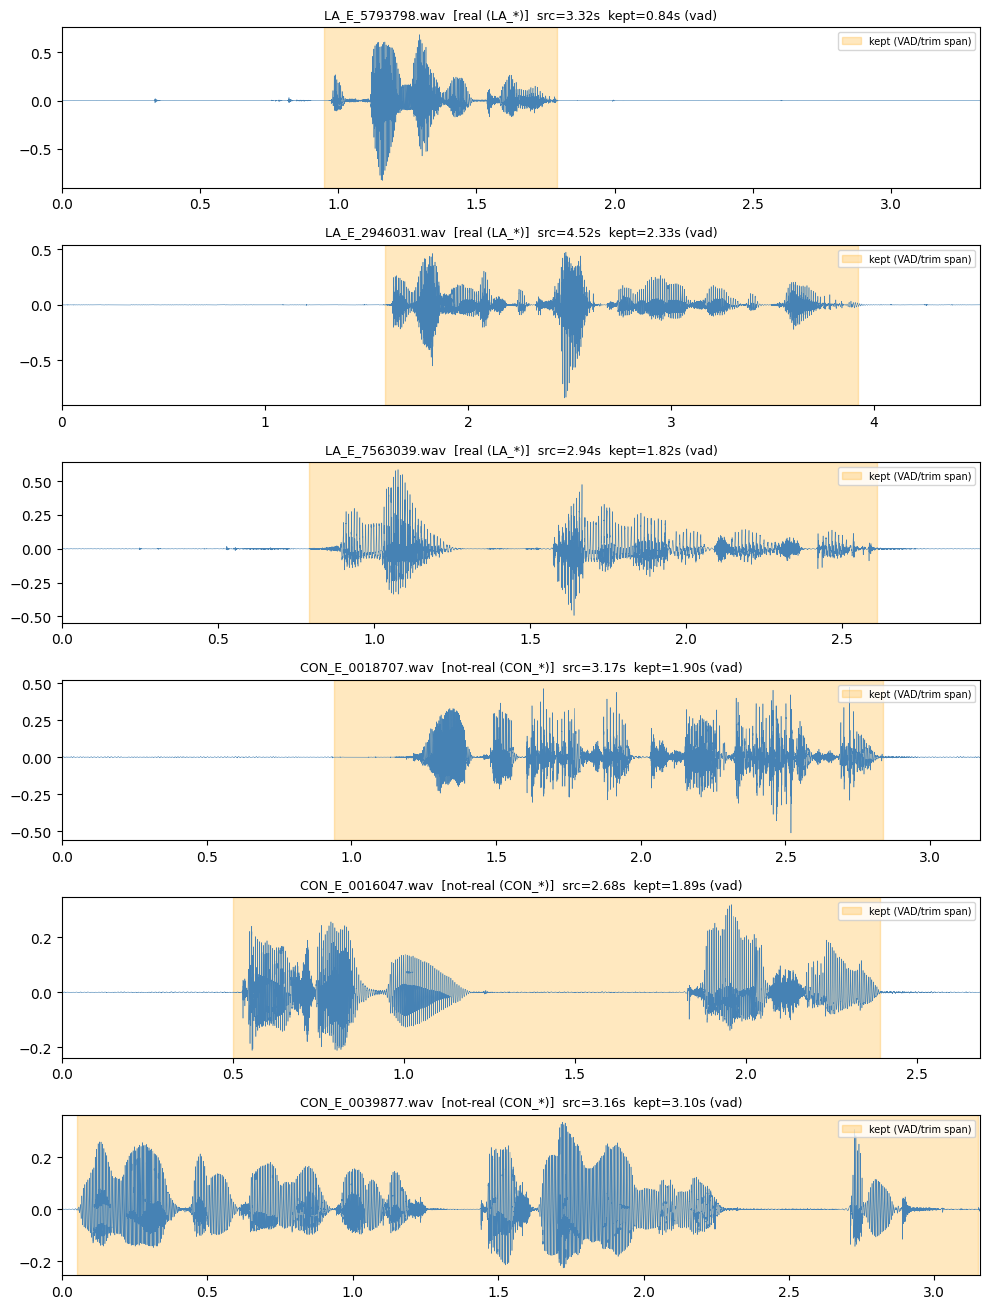

Saved plot to /kaggle/working/vad_trim_sanity_check.png


In [15]:
# ==============================================================================
# CELL 9.3: Three sanity checks on the VAD-trimming pipeline before trusting
# the Cell 9.2 result.
#   (1) Per-clip trimmed duration vs source duration — not just the aggregate
#       mean, so we can see whether the 2.41s figure is uniform or driven by
#       a subset of over-trimmed clips.
#   (2) VAD label-convention check — confirm label==2 really means
#       "non-speech" consistently across files, and see how much of each
#       file's duration is being classified as non-speech overall.
#   (3) Waveform sanity check on a handful of clips — plot raw vs VAD-trimmed
#       waveform with the kept span shaded, so we can visually confirm real
#       speech isn't being clipped.
# ==============================================================================

import matplotlib.pyplot as plt

_rng_check = random.Random(SEED)
sample_examples = _rng_check.sample(partialspoof_binary_examples, 300)

# ---- (1) Per-clip trimmed vs source duration -------------------------------
rows = []
for wav_path, label in tqdm(sample_examples, desc="per-clip duration check"):
    src_dur = librosa.get_duration(path=str(wav_path))
    vad_path = PS_EVAL_VAD_DIR / f"{wav_path.stem}.vad"
    span = load_vad_speech_span(vad_path)
    source = "vad"
    if span is None:
        y, _ = librosa.load(str(wav_path), sr=SR, mono=True)
        span = energy_trim_span(y)
        source = "energy_fallback"
    trimmed_dur = span[1] - span[0]
    rows.append((wav_path, label, src_dur, trimmed_dur, source))

src_durs     = np.array([r[2] for r in rows])
trimmed_durs = np.array([r[3] for r in rows])
kept_frac    = trimmed_durs / np.clip(src_durs, 1e-6, None)

print("=" * 70)
print("(1) Per-clip trimmed vs source duration (n={})".format(len(rows)))
print("=" * 70)
print(f"  Mean source duration:  {src_durs.mean():.2f}s")
print(f"  Mean trimmed duration: {trimmed_durs.mean():.2f}s")
print(f"  Mean kept fraction (trimmed/source): {kept_frac.mean():.1%}")
print(f"  Median kept fraction:                {np.median(kept_frac):.1%}")
print(f"  Clips where kept fraction < 50%:      {(kept_frac < 0.5).mean():.1%}")
print(f"  Clips where kept fraction < 25%:      {(kept_frac < 0.25).mean():.1%}")
print(f"  Clips where trimmed_dur > source_dur (bug check): {(trimmed_durs > src_durs + 1e-6).sum()}")
n_fallback = sum(1 for r in rows if r[4] == "energy_fallback")
print(f"  Fell back to energy-trim: {n_fallback} / {len(rows)}")

worst = sorted(rows, key=lambda r: r[3] / max(r[2], 1e-6))[:5]
print("\n  5 most aggressively trimmed clips (lowest kept fraction):")
for wav_path, label, s, t, src in worst:
    print(f"    {wav_path.name:30s} src={s:.2f}s  trimmed={t:.2f}s  "
          f"kept={t/max(s,1e-6):.1%}  source={src}")

# ---- (2) VAD label-convention check ----------------------------------------
print("\n" + "=" * 70)
print("(2) VAD label distribution across files")
print("=" * 70)
label_durations = {0: 0.0, 1: 0.0, 2: 0.0}
label_counts    = {0: 0, 1: 0, 2: 0}
n_vad_files = 0
for wav_path, label in sample_examples:
    vad_path = PS_EVAL_VAD_DIR / f"{wav_path.stem}.vad"
    if not vad_path.exists():
        continue
    n_vad_files += 1
    for s, e, lab in parse_vad_file(vad_path):
        label_durations[lab] = label_durations.get(lab, 0.0) + (e - s)
        label_counts[lab] = label_counts.get(lab, 0) + 1

total_dur = sum(label_durations.values())
print(f"  Files with a .vad file: {n_vad_files} / {len(sample_examples)}")
for lab in sorted(label_durations):
    frac = label_durations[lab] / total_dur if total_dur > 0 else 0
    print(f"  label={lab}: {label_counts[lab]:5d} intervals, "
          f"{label_durations[lab]:8.1f}s total ({frac:.1%} of all annotated time)")
print("  (sanity: label 2 should be a small, plausible fraction of total "
      "duration if it really is 'non-speech'; if it's the majority label, "
      "the convention may not be what Cell 9.1 assumes)")

# ---- (3) Waveform sanity check on a handful of clips -----------------------
print("\n" + "=" * 70)
print("(3) Waveform sanity check — plotting 3 real + 3 not-real examples")
print("=" * 70)
plot_examples = (
    _rng_check.sample([r for r in rows if r[1] == 0], 3) +
    _rng_check.sample([r for r in rows if r[1] == 1], 3)
)

fig, axes = plt.subplots(len(plot_examples), 1, figsize=(10, 2.2 * len(plot_examples)))
for ax, (wav_path, label, src_dur, trimmed_dur, source) in zip(axes, plot_examples):
    y, _ = librosa.load(str(wav_path), sr=SR, mono=True)
    t = np.arange(len(y)) / SR
    ax.plot(t, y, linewidth=0.4, color="steelblue")

    vad_path = PS_EVAL_VAD_DIR / f"{wav_path.stem}.vad"
    span = load_vad_speech_span(vad_path)
    if span is None:
        span = energy_trim_span(y)
    ax.axvspan(span[0], span[1], color="orange", alpha=0.25, label="kept (VAD/trim span)")

    lbl_name = "real (LA_*)" if label == 0 else "not-real (CON_*)"
    ax.set_title(f"{wav_path.name}  [{lbl_name}]  src={src_dur:.2f}s  "
                  f"kept={trimmed_dur:.2f}s ({source})", fontsize=9)
    ax.set_xlim(0, max(t[-1], 0.1))
    ax.legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.savefig("/kaggle/working/vad_trim_sanity_check.png", dpi=120)
plt.show()
print("Saved plot to /kaggle/working/vad_trim_sanity_check.png")

In [16]:
# ==============================================================================
# CELL 9: Parameter footprint and CPU inference-latency benchmark
# Answers "how lightweight is CAFNet in practice" with disk size + per-clip
# CPU latency, not just parameter count. Reuses `cafnet` (already loaded)
# and CAFNET_CKPT (already defined in Cell 1). No new data needed.
# ==============================================================================

import time
import os

# ── Disk footprint ──────────────────────────────
ckpt_size_mb = os.path.getsize(CAFNET_CKPT) / (1024 ** 2)
n_params = sum(p.numel() for p in cafnet.parameters())

print(f"Checkpoint size on disk : {ckpt_size_mb:.2f} MB")
print(f"Total parameters        : {n_params:,}")

# ── CPU inference latency ───────────────────────
cafnet.eval()
cafnet_cpu = cafnet.to("cpu")

# Dummy input matching real feature shapes (N_MFCC/N_LFCC=40, N_CHROMA=12, N_FRAMES=251)
dummy_m = torch.randn(1, 1, N_MFCC, N_FRAMES)
dummy_l = torch.randn(1, 1, N_LFCC, N_FRAMES)
dummy_c = torch.randn(1, 1, N_CHROMA, N_FRAMES)

N_WARMUP = 10
N_RUNS   = 100

with torch.no_grad():
    for _ in range(N_WARMUP):
        _ = cafnet_cpu(dummy_m, dummy_l, dummy_c)

    latencies = []
    for _ in range(N_RUNS):
        t0 = time.perf_counter()
        _ = cafnet_cpu(dummy_m, dummy_l, dummy_c)
        latencies.append((time.perf_counter() - t0) * 1000)  # ms

latencies = np.array(latencies)
print(f"\nCPU inference latency over {N_RUNS} runs (single 4s clip, forward pass only):")
print(f"  Mean   : {latencies.mean():.2f} ms")
print(f"  Median : {np.median(latencies):.2f} ms")
print(f"  p90    : {np.percentile(latencies, 90):.2f} ms")
print(f"  (torch threads: {torch.get_num_threads()})")

Checkpoint size on disk : 2.24 MB
Total parameters        : 576,027

CPU inference latency over 100 runs (single 4s clip, forward pass only):
  Mean   : 14.42 ms
  Median : 14.41 ms
  p90    : 14.80 ms
  (torch threads: 2)


In [6]:
# add to cross-dataset-eval.ipynb, after had_entries is built (Cell 4a)
had_total_durations = np.array([e['segments'][-1][1] for e in had_entries.values()])
n = len(had_total_durations)
over4 = had_total_durations > 4.0
print(f"HAD test set: n={n}")
print(f"  mean={had_total_durations.mean():.2f}s  longest={had_total_durations.max():.2f}s")
print(f"  clips > 4.0s: {over4.sum()} ({over4.mean():.1%})")
print(f"  mean duration of >4s subset: {had_total_durations[over4].mean():.2f}s")

HAD test set: n=9072
  mean=4.27s  longest=60.00s
  clips > 4.0s: 4638 (51.1%)
  mean duration of >4s subset: 5.46s


In [5]:
idx = np.argmax(had_total_durations)
uttid = list(had_entries.keys())[idx]
print(uttid, had_entries[uttid])

HAD_test_00002179 {'overall': 0, 'segments': [(0.0, 60.0, 'F')], 'class': 'fake', 'splice_start': None, 'splice_end': None, 'n_f_regions': 1}


In [10]:
# ==============================================================================
# FINAL CELL — Re-evaluate the FULL (aux-head) architecture on HAD + PartialSpoof
# for the old-vs-new comparison. Does NOT touch any existing no_aux_head_seed42
# results already computed above — all variables here are prefixed full_.
# ==============================================================================

# --- 1. Load the FULL architecture class -------------------------------------
class EnhancedPathAblatable(nn.Module):
    """use_self_attn=False removes the SelfAttn1d refinement (Identity instead)."""
    def __init__(self, in_ch, use_self_attn=True):
        super().__init__()
        self.net = nn.Sequential(
            DSConv1d(in_ch,64,3,1), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            DSConv1d(64,128,3,1),   nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3))
        self.attn = SelfAttn1d(128) if use_self_attn else nn.Identity()
        self.pool = nn.MaxPool1d(2)
    def forward(self, x):
        return self.pool(self.attn(self.net(x.squeeze(1))))

class CrossAttnFusion(nn.Module):
    """Original fusion mechanism (cross-attention + gating)."""
    def __init__(self, dim=128):
        super().__init__()
        self.ca = nn.MultiheadAttention(dim, num_heads=8, batch_first=True)
        self.gate = nn.Linear(dim*3, 3)
        self.proj = nn.Linear(dim, dim)
    def forward(self, m, l, c):
        ms, ls, cs = m.permute(0,2,1), l.permute(0,2,1), c.permute(0,2,1)
        kv = torch.cat([ls, cs], dim=1)
        attn_out, _ = self.ca(ms, kv, kv)
        mp, lp, cp = ms.mean(1), ls.mean(1), cs.mean(1)
        gates = F.softmax(self.gate(torch.cat([mp,lp,cp], dim=1)), dim=1)
        fused = gates[:,0:1]*mp + gates[:,1:2]*lp + gates[:,2:3]*cp
        return self.proj(fused)

class ConcatFusion(nn.Module):
    """Ablation: replace cross-attention with plain mean-pool + concat + linear
    (this is the fusion mechanism the paper compares against only under
    MFAAN's architecture in Cell 16 — never under CAFNet's own backbone)."""
    def __init__(self, dim=128):
        super().__init__()
        self.proj = nn.Linear(dim*3, dim)
    def forward(self, m, l, c):
        return self.proj(torch.cat([m.mean(-1), l.mean(-1), c.mean(-1)], dim=1))
        
class CAFNetAblatable(nn.Module):
    def __init__(self, use_cross_attn=True, use_self_attn=True, use_aux_head=True):
        super().__init__()
        self.use_aux_head = use_aux_head
        self.mfcc_p   = EnhancedPathAblatable(N_MFCC,   use_self_attn)
        self.lfcc_p   = EnhancedPathAblatable(N_LFCC,   use_self_attn)
        self.chroma_p = EnhancedPathAblatable(N_CHROMA, use_self_attn)
        self.fusion   = CrossAttnFusion(128) if use_cross_attn else ConcatFusion(128)
        self.head = nn.Sequential(
            nn.Linear(128,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, CAF_CLASSES))
        self.aux = nn.Linear(128, CAF_CLASSES) if use_aux_head else None
        self.temporal = TemporalHead()
    def forward(self, mfcc, lfcc, chroma):
        mf, lf, cf = self.mfcc_p(mfcc), self.lfcc_p(lfcc), self.chroma_p(chroma)
        pre_pool = torch.cat([mf, lf, cf], dim=1)
        fused = self.fusion(mf, lf, cf)
        cls_main = self.head(fused)
        cls_aux  = self.aux(fused) if self.use_aux_head else None
        temporal = self.temporal(pre_pool)
        return cls_main, cls_aux, temporal

FULL_CKPT = Path("/kaggle/input/models/piwoobeep/cafnet-unified-pth/pytorch/default/1/cafnet_unified.pth")

full_model = CAFNetAblatable(use_cross_attn=True, use_self_attn=True, use_aux_head=True)
full_model.load_state_dict(torch.load(FULL_CKPT, map_location=DEVICE))
full_model.to(DEVICE).eval()
print(f"Loaded FULL (aux-head) checkpoint. Params: {sum(p.numel() for p in full_model.parameters()):,}")

_dummy = (torch.randn(1,1,N_MFCC,N_FRAMES), torch.randn(1,1,N_LFCC,N_FRAMES), torch.randn(1,1,N_CHROMA,N_FRAMES))
with torch.no_grad():
    _out = full_model(*[t.to(DEVICE) for t in _dummy])
print(f"forward() returns {len(_out)} outputs: {[o.shape for o in _out]}")

# --- 2. HAD detection rate ----------------------------------------------------
print("="*70); print("FULL ARCH — HAD detection rate"); print("="*70)
full_had_results = eval_detection_rate(full_model, had_entries, HAD_TEST_WAV_DIR, DEVICE)
for k, v in full_had_results.items():
    print(f"  {k:12s} recall={v['recall']:.4f}  (n={v['n']})")

# --- 3. PartialSpoof zero-shot binary + paired TPR/FPR ------------------------
print("="*70); print("FULL ARCH — PartialSpoof zero-shot binary"); print("="*70)
full_ps_results = eval_zero_shot_binary(full_model, partialspoof_binary_examples, DEVICE)
print(f"  AUC={full_ps_results['auc']:.4f}  EER={full_ps_results['eer']:.4f}  "
      f"Acc={full_ps_results['acc']:.4f}  (n={full_ps_results['n']})")
full_ps_paired = eval_paired_rate(full_model, partialspoof_binary_examples, DEVICE)
print(f"  TPR(CON_*)={full_ps_paired['tpr_detection_rate']:.4f}  "
      f"FPR(LA_*)={full_ps_paired['fpr_false_alarm_rate']:.4f}")

# --- 4. HAD ternary prediction distribution ------------------------------------
print("="*70); print("FULL ARCH — HAD ternary distribution"); print("="*70)
full_prediction_distribution(full_model, had_entries, HAD_TEST_WAV_DIR)

# --- 5. HAD localization (random-offset oracle, same protocol as canonical) --
print("="*70); print("FULL ARCH — HAD localization"); print("="*70)
full_start_errs, full_end_errs, n_skipped = [], [], 0
for uttid, e in tqdm(had_entries.items(), desc="FULL arch HAD localization"):
    if e['class'] != 'halftruth':
        continue
    splice_start, splice_end = e['splice_start'], e['splice_end']
    if splice_end - splice_start > WIN_DURATION:
        n_skipped += 1
        continue
    wav_path = HAD_TEST_WAV_DIR / f"{uttid}.wav"
    y, _ = librosa.load(str(wav_path), sr=SR, mono=True)
    result = random_offset_crop_and_predict(full_model, y, splice_start, splice_end)
    full_start_errs.append(abs(result['pred_start_s'] - splice_start))
    full_end_errs.append(abs(result['pred_end_s'] - splice_end))

full_start_errs = np.array(full_start_errs)
full_end_errs = np.array(full_end_errs)
full_overall_errs = (full_start_errs + full_end_errs) / 2
print(f"Skipped (splice > 4.0s): {n_skipped}   Evaluated: {len(full_start_errs)}")
for name, arr in [("Start", full_start_errs), ("End", full_end_errs), ("Overall", full_overall_errs)]:
    print(f"  {name:8s} MAE={arr.mean():.3f}s  Median={np.median(arr):.3f}s  p90={np.percentile(arr,90):.3f}s")

Loaded FULL (aux-head) checkpoint. Params: 576,414
forward() returns 3 outputs: [torch.Size([1, 3]), torch.Size([1, 3]), torch.Size([1, 2])]
FULL ARCH — HAD detection rate


detection rate:   0%|          | 0/9072 [00:00<?, ?it/s]

  fake         recall=0.8590  (n=234)
  halftruth    recall=0.7697  (n=8838)
  overall      recall=0.7720  (n=9072)
FULL ARCH — PartialSpoof zero-shot binary


binary eval:   0%|          | 0/14000 [00:00<?, ?it/s]

  AUC=0.4578  EER=0.5253  Acc=0.4994  (n=14000)


...

  TPR(CON_*)=0.9444  FPR(LA_*)=0.9887
FULL ARCH — HAD ternary distribution


full prediction pass:   0%|          | 0/9072 [00:00<?, ?it/s]

true=fake        pred distribution: {'fake': 201, 'real': 33}
true=halftruth   pred distribution: {'fake': 6415, 'real': 2142, 'half-truth': 281}
FULL ARCH — HAD localization


FULL arch HAD localization:   0%|          | 0/9072 [00:00<?, ?it/s]

TypeError: tuple indices must be integers or slices, not str

In [14]:
# ==============================================================================
# FIX v2 — FULL ARCH HAD localization, correct window-relative comparison
# ==============================================================================

full_start_errs, full_end_errs, n_skipped = [], [], 0
for uttid, e in tqdm(had_entries.items(), desc="FULL arch HAD localization"):
    if e['class'] != 'halftruth':
        continue
    splice_start, splice_end = e['splice_start'], e['splice_end']
    if splice_end - splice_start > WIN_DURATION:
        n_skipped += 1
        continue
    wav_path = HAD_TEST_WAV_DIR / f"{uttid}.wav"
    y, _ = librosa.load(str(wav_path), sr=SR, mono=True)

    pred_start_s, pred_end_s, true_start_w, true_end_w = random_offset_crop_and_predict(
        full_model, y, splice_start, splice_end
    )

    full_start_errs.append(abs(pred_start_s - true_start_w))
    full_end_errs.append(abs(pred_end_s - true_end_w))

full_start_errs = np.array(full_start_errs)
full_end_errs = np.array(full_end_errs)
full_overall_errs = (full_start_errs + full_end_errs) / 2
print(f"Skipped (splice > 4.0s): {n_skipped}   Evaluated: {len(full_start_errs)}")
for name, arr in [("Start", full_start_errs), ("End", full_end_errs), ("Overall", full_overall_errs)]:
    print(f"  {name:8s} MAE={arr.mean():.3f}s  Median={np.median(arr):.3f}s  p90={np.percentile(arr,90):.3f}s")

FULL arch HAD localization:   0%|          | 0/9072 [00:00<?, ?it/s]

Skipped (splice > 4.0s): 7   Evaluated: 8831
  Start    MAE=0.765s  Median=0.573s  p90=1.770s
  End      MAE=0.906s  Median=0.729s  p90=1.998s
  Overall  MAE=0.835s  Median=0.603s  p90=1.841s
